<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
import gradio as gr

# Загрузка данных Boston Housing
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X = data
y = target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Масштабирование целевой переменной (улучшает сходимость)
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_503/1390420109.py:14: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


#### 1.2. Проектируем архитектуру для этой задачи

In [12]:
def create_regression_model(input_dim):
    model = Sequential([
        Dense(64, input_dim=input_dim, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')  # Выход для регрессии
    ])
    return model

model = create_regression_model(X_train_scaled.shape[1])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [13]:
# Для регрессии: MSE как loss, MAE как метрика
model.compile(
    optimizer=SGD(learning_rate=0.01),  # или Adam(learning_rate=0.001)
    loss='mean_squared_error',
    metrics=['mae', 'mape']
)

#### 1.4. Обучаем модель ИНС

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.2160 - mae: 0.3858 - mape: 184556.0781 - val_loss: 0.0647 - val_mae: 0.1808 - val_mape: 54.1724
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0760 - mae: 0.2015 - mape: 914940.3750 - val_loss: 0.0481 - val_mae: 0.1539 - val_mape: 57.6485
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0634 - mae: 0.1787 - mape: 669080.5625 - val_loss: 0.0446 - val_mae: 0.1499 - val_mape: 60.3367
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0508 - mae: 0.1649 - mape: 596160.6250 - val_loss: 0.0427 - val_mae: 0.1481 - val_mape: 61.0281
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0546 - mae: 0.1691 - mape: 222916.7500 - val_loss: 0.0413 - val_mae: 0.1471 - val_mape: 61.4975
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0467 - mae: 0.1590 - mape: 569695.7500 - val_loss: 0.0398 - val_mae: 0.1430 - val_mape: 58.9272
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss

#### 1.6. Делаем предсказания на тестовых данных

In [15]:
# Предсказание в масштабированных значениях
preds_scaled = model.predict(X_test_scaled, verbose=0)

# Обратное преобразование к исходному масштабу
y_pred = y_scaler.inverse_transform(preds_scaled).flatten()

#### 1.7. Вычисляем метрику качества на тестовых данных

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test R²: {r2_score(y_test, y_pred):.4f}")

Test RMSE: 6.02
Test MAE: 3.89
Test R²: 0.5061


#### 1.8. Строим график обучения

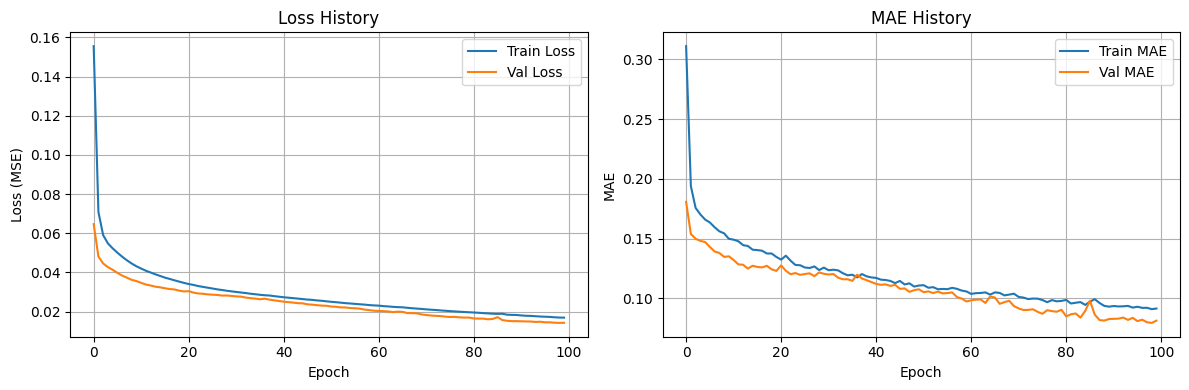

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss History')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE History')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [25]:
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

def predict_price(*features):
    try:
        input_data = np.array(features).reshape(1, -1)
        input_scaled = scaler.transform(input_data)

        pred_scaled = model.predict(input_scaled, verbose=0)[0][0]
        pred_original = y_scaler.inverse_transform([[pred_scaled]])[0][0]

        return f"Прогноз цены: ${pred_original*1000:,.2f}"
    except Exception as e:
        return f"Ошибка: {str(e)}"

demo = gr.Interface(
    fn=predict_price,
    inputs=[gr.Number(label=name, value=0.0) for name in feature_names],
    outputs=gr.Textbox(label="Результат"),
    title="Boston Housing Price Predictor",
    description="Введите 13 характеристик недвижимости"
)

demo.launch(server_name="0.0.0.0", server_port=7000)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bea32d1a82ec545fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
# Ваш код

## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [26]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow


### 2. Загружаем набор данных:

In [28]:

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pickle


# Путь к датасету на Google Drive
DATASET_PATH = '/content/drive/MyDrive/animals/train'
VAL_PATH = '/content/drive/MyDrive/animals/val'

# Параметры изображений
IMG_SIZE = 64  # Размер изображения (64x64 пикселя)
INPUT_DIM = IMG_SIZE * IMG_SIZE * 3  # Размер входного вектора

# Параметры обучения
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

print(f"📊 Параметры модели:")
print(f"   Размер изображения: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Входной вектор: {INPUT_DIM} признаков")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Эпох: {EPOCHS}")

def load_dataset_from_folders(base_path, img_size=64):
    """
    Загрузка изображений из структуры папок:
    base_path/
        class1/
            img1.jpg
            img2.jpg
        class2/
            img1.jpg
            ...
    """
    data = []
    labels = []
    class_names = []

    # Получаем список классов (папок)
    classes = sorted([d for d in os.listdir(base_path)
                     if os.path.isdir(os.path.join(base_path, d))])

    print(f"\n📁 Найдено классов: {len(classes)}")
    print(f"   Классы: {classes}")

    class_names = classes

    # Загружаем изображения для каждого класса
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        print(f"\n📂 Класс '{class_name}': {len(image_files)} изображений")

        for img_file in image_files:
            try:
                img_path = os.path.join(class_path, img_file)

                # Чтение изображения
                img = cv2.imread(img_path)
                if img is None:
                    continue

                # Изменение размера
                img = cv2.resize(img, (img_size, img_size))

                # Преобразование BGR -> RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Flatten в вектор
                img_vector = img.flatten()

                data.append(img_vector)
                labels.append(class_name)

            except Exception as e:
                print(f"⚠️  Ошибка загрузки {img_file}: {e}")
                continue

    # Преобразование в numpy массивы
    data = np.array(data, dtype='float32')
    labels = np.array(labels)

    # Нормализация [0, 1]
    data /= 255.0

    print(f"\n✅ Загружено всего: {len(data)} изображений")
    print(f"   Размерность данных: {data.shape}")

    return data, labels, class_names

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Параметры модели:
   Размер изображения: 64x64
   Входной вектор: 12288 признаков
   Batch size: 32
   Эпох: 50


### 3. Указываем путь к набору данных:

In [ ]:
# Ваш код

### 4. Загружаем набор данных и формируем общую выборку:

In [29]:
print("="*60)
print("ЗАГРУЗКА ОБУЧАЮЩИХ ДАННЫХ")
print("="*60)

X_train, y_train_str, class_names = load_dataset_from_folders(
    DATASET_PATH,
    img_size=IMG_SIZE
)

print("\n" + "="*60)
print("ЗАГРУЗКА ВАЛИДАЦИОННЫХ ДАННЫХ")
print("="*60)

X_val, y_val_str, _ = load_dataset_from_folders(
    VAL_PATH,
    img_size=IMG_SIZE
)

ЗАГРУЗКА ОБУЧАЮЩИХ ДАННЫХ

📁 Найдено классов: 5
   Классы: ['cat', 'dog', 'elephant', 'horse', 'lion']

📂 Класс 'cat': 2737 изображений

📂 Класс 'dog': 2627 изображений

📂 Класс 'elephant': 2730 изображений

📂 Класс 'horse': 2705 изображений

📂 Класс 'lion': 2675 изображений

✅ Загружено всего: 13474 изображений
   Размерность данных: (13474, 12288)

ЗАГРУЗКА ВАЛИДАЦИОННЫХ ДАННЫХ

📁 Найдено классов: 5
   Классы: ['cat', 'dog', 'elephant', 'horse', 'lion']

📂 Класс 'cat': 300 изображений

📂 Класс 'dog': 300 изображений

📂 Класс 'elephant': 299 изображений

📂 Класс 'horse': 300 изображений

📂 Класс 'lion': 298 изображений

✅ Загружено всего: 1497 изображений
   Размерность данных: (1497, 12288)


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности



КОДИРОВАНИЕ МЕТОК КЛАССОВ
Классы: ['cat' 'dog' 'elephant' 'horse' 'lion']
Форма train меток: (13474, 5)
Форма val меток: (1497, 5)

📊 Примеры обучающих данных:


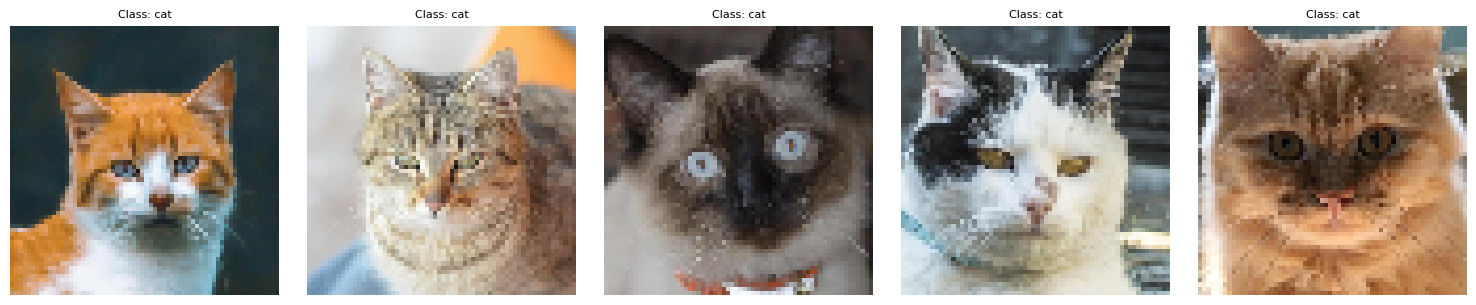

In [30]:

print("\n" + "="*60)
print("КОДИРОВАНИЕ МЕТОК КЛАССОВ")
print("="*60)

# One-Hot Encoding
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train_str)
y_val = lb.transform(y_val_str)

print(f"Классы: {lb.classes_}")
print(f"Форма train меток: {y_train.shape}")
print(f"Форма val меток: {y_val.shape}")

def visualize_samples(X, y, class_names, num_samples=5):
    """Визуализация примеров из каждого класса"""
    plt.figure(figsize=(15, 3))

    for i in range(min(num_samples, len(X))):
        # Восстановление изображения из вектора
        img = X[i].reshape(IMG_SIZE, IMG_SIZE, 3)

        # Определение класса
        label_idx = np.argmax(y[i]) if len(y[i]) > 1 else y[i][0]
        label = class_names[label_idx]

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"Class: {label}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\n📊 Примеры обучающих данных:")
visualize_samples(X_train, y_train, class_names, num_samples=5)

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
# Ваш код

### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


num_classes = len(class_names)

def create_dense_model(input_dim, num_classes):
    """Создание полносвязной нейронной сети"""
    model = Sequential([
        # Первый слой
        Dense(1024, input_dim=input_dim, activation='relu',
              kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),

        # Второй слой
        Dense(512, activation='relu',
              kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),

        # Третий слой
        Dense(256, activation='relu',
              kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),

        # Четвертый слой
        Dense(128, activation='relu',
              kernel_regularizer=l2(0.001)),
        Dropout(0.2),

        # Выходной слой
        Dense(num_classes, activation='softmax')
    ])

    return model

model = create_dense_model(INPUT_DIM, num_classes)
model.summary()



СОЗДАНИЕ МОДЕЛИ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1024)           │    12,583,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,280,773 (50.66 MB)

 Trainable params: 13,277,189 (50.65 MB)

 Non-trainable params: 3,584 (14.00 KB)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [32]:

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

#### 5.3. Компилируем модель:

In [33]:
print("\n" + "="*60)
print("КОМПИЛЯЦИЯ МОДЕЛИ")
print("="*60)

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', 'top_k_categorical_accuracy']
)

print(f"Модель скомпилирована")
print(f"   Оптимизатор: Adam")
print(f"   Функция потерь: categorical_crossentropy")
print(f"   Метрики: accuracy, top_k_categorical_accuracy")



КОМПИЛЯЦИЯ МОДЕЛИ
Модель скомпилирована
   Оптимизатор: Adam
   Функция потерь: categorical_crossentropy
   Метрики: accuracy, top_k_categorical_accuracy


### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [34]:
print("\n" + "="*60)
print("НАСТРОЙКА КОЛБЭКОВ")
print("="*60)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_animals_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Колбэки настроены:")
print("   - EarlyStopping (patience=10)")
print("   - ModelCheckpoint (сохранение лучшей модели)")
print("   - ReduceLROnPlateau (уменьшение learning rate)")



НАСТРОЙКА КОЛБЭКОВ
✅ Колбэки настроены:
   - EarlyStopping (patience=10)
   - ModelCheckpoint (сохранение лучшей модели)
   - ReduceLROnPlateau (уменьшение learning rate)


#### 6.2. Запустим процесс обучения модели:

In [35]:
print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


НАЧАЛО ОБУЧЕНИЯ
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3475 - loss: 4.4704 - top_k_categorical_accuracy: 1.0000
Epoch 1: val_accuracy improved from -inf to 0.41617, saving model to best_animals_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.3476 - loss: 4.4689 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4162 - val_loss: 2.9763 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 2/50
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4554 - loss: 2.7679 - top_k_categorical_accuracy: 1.0000
Epoch 2: val_accuracy did not improve from 0.41617
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4556 - loss: 2.7657 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.3033 - val_loss: 3.0190 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 3/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4831 - loss: 2.3251 - top_k_categorical_accuracy: 1.0000
Epoch 3: val_accuracy did not improve from 0.41617
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4832 - loss: 2.3246 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.3741 - val_loss: 2.3706 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4789 - loss: 1.7801 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4703 - val_loss: 1.7864 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 9/50
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4892 - loss: 1.7072 - top_k_categorical_accuracy: 1.0000
Epoch 9: val_accuracy did not improve from 0.47027
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4892 - loss: 1.7070 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.3367 - val_loss: 1.8946 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 10/50
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4809 - loss: 1.6654 - top_k_categorical_accuracy: 1.0000
Epoch 10: val_accuracy did not improve from 0.47027
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4809 - loss: 1.6656 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.2077 - val_loss: 2.4258 - val_top_k_categorical_accuracy: 1.0000 - learning_rate:

422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5114 - loss: 1.4052 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4743 - val_loss: 1.4559 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 2.5000e-04
Epoch 21/50
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5381 - loss: 1.3504 - top_k_categorical_accuracy: 1.0000
Epoch 21: val_accuracy improved from 0.47428 to 0.56513, saving model to best_animals_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5381 - loss: 1.3501 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5651 - val_loss: 1.2415 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 2.5000e-04
Epoch 22/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5593 - loss: 1.2775 - top_k_categorical_accuracy: 1.0000
Epoch 22: val_accuracy did not improve from 0.56513
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5593 - loss: 1.2775 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5110 - val_loss: 1.3443 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 2.5000e-04
Epoch 23/50
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5407 - loss: 1.3070 - top_k_categorical_accuracy: 1.0000
Epoch 23: val_accuracy did not improve from 0.56513
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5406 - loss: 1.3070 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4623 - val_loss: 1.4532 - val_top_k_categorical_accuracy: 1.0000 - learn

422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5886 - loss: 1.1491 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5678 - val_loss: 1.1743 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 31/50
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5980 - loss: 1.1299 - top_k_categorical_accuracy: 1.0000
Epoch 31: val_accuracy did not improve from 0.56780
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5979 - loss: 1.1300 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4582 - val_loss: 1.4328 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 32/50
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5998 - loss: 1.1321 - top_k_categorical_accuracy: 1.0000
Epoch 32: val_accuracy improved from 0.56780 to 0.58584, saving model to best_animals_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5997 - loss: 1.1323 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5858 - val_loss: 1.1415 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 33/50
415/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6015 - loss: 1.1217 - top_k_categorical_accuracy: 1.0000
Epoch 33: val_accuracy improved from 0.58584 to 0.59987, saving model to best_animals_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6015 - loss: 1.1216 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5999 - val_loss: 1.0987 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 34/50
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6105 - loss: 1.0970 - top_k_categorical_accuracy: 1.0000
Epoch 34: val_accuracy did not improve from 0.59987
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6103 - loss: 1.0972 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4910 - val_loss: 1.3963 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 35/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6027 - loss: 1.1235 - top_k_categorical_accuracy: 1.0000
Epoch 35: val_accuracy did not improve from 0.59987
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6026 - loss: 1.1236 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5591 - val_loss: 1.2015 - val_top_k_categorical_accuracy: 1.0000 - learn

422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6073 - loss: 1.1122 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.6092 - val_loss: 1.1078 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 38/50
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6062 - loss: 1.0916 - top_k_categorical_accuracy: 1.0000
Epoch 38: val_accuracy did not improve from 0.60922
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6063 - loss: 1.0916 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.6072 - val_loss: 1.0849 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.2500e-04
Epoch 39/50
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6154 - loss: 1.0783 - top_k_categorical_accuracy: 1.0000
Epoch 39: val_accuracy did not improve from 0.60922
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6153 - loss: 1.0785 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5585 - val_loss: 1.1993 - val_top_k_categorical_accuracy: 1.0000 - learn

#### 6.3. Загружаем лучшую модель:

In [ ]:
# Ваш код

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [36]:
print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("="*60)

# Загрузка лучшей модели
model.load_weights('best_animals_model.h5')

# Предсказания
y_pred = model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# Отчёт классификации
print("\n📊 Classification Report:")
print(classification_report(
    y_val_classes,
    y_pred_classes,
    target_names=class_names
))


ОЦЕНКА КАЧЕСТВА МОДЕЛИ



📊 Classification Report:
              precision    recall  f1-score   support

         cat       0.85      0.62      0.72       300
         dog       0.70      0.73      0.71       300
    elephant       0.51      0.50      0.50       299
       horse       0.54      0.46      0.50       300
        lion       0.53      0.74      0.62       298

    accuracy                           0.61      1497
   macro avg       0.63      0.61      0.61      1497
weighted avg       0.63      0.61      0.61      1497



#### 7.2. Выведем матрицу ошибок

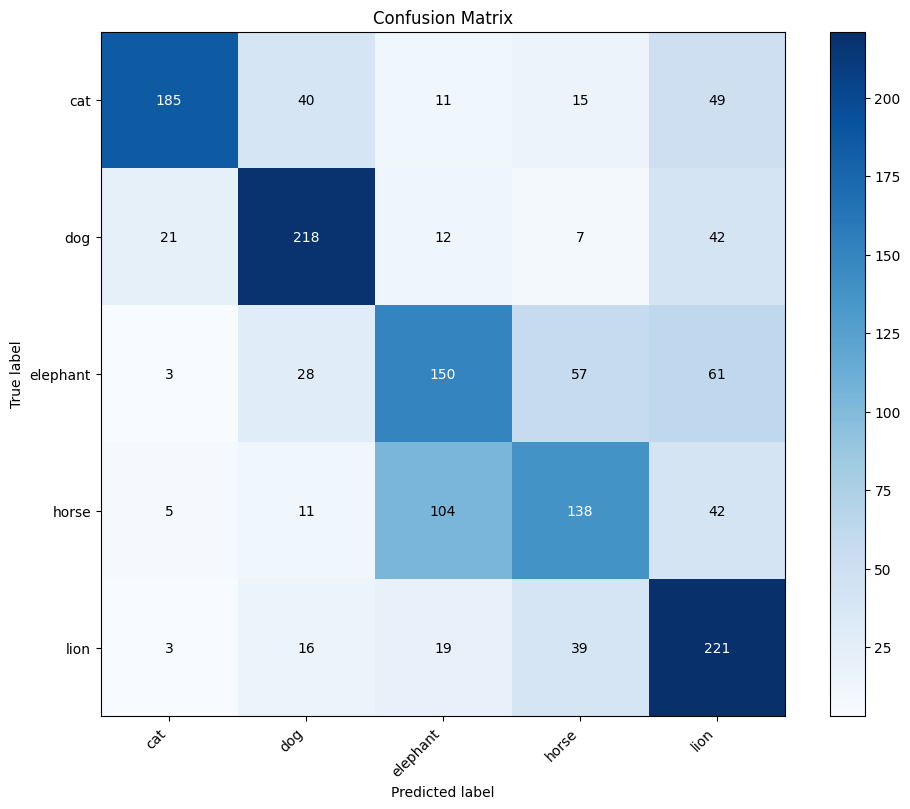

In [37]:
cm = confusion_matrix(y_val_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

# Добавление значений
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#### 7.3. Отобразим график обучения


📈 Графики обучения:


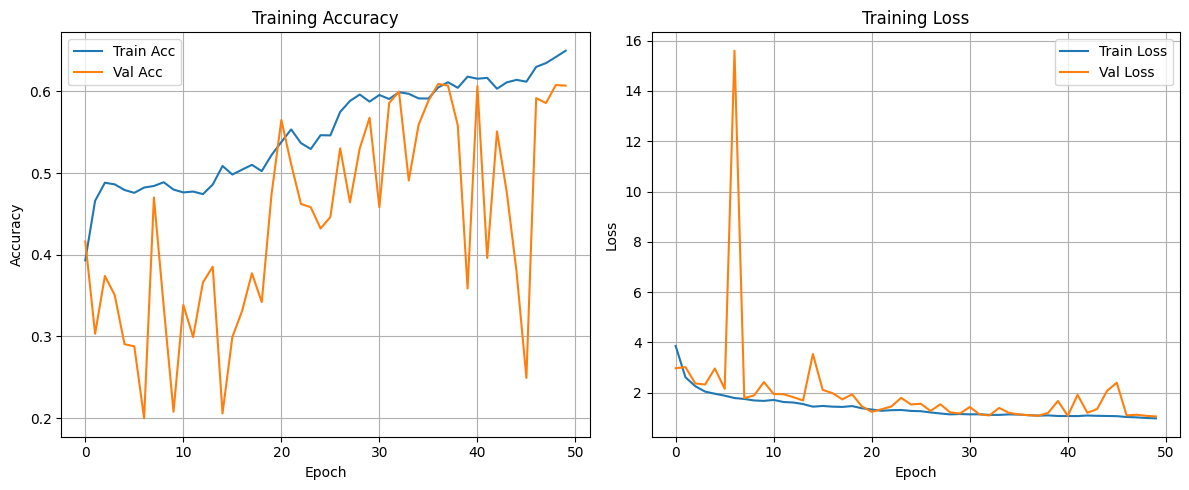

In [38]:
print("\n📈 Графики обучения:")

plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 8. Сохранение модели и меток классов:

In [39]:
model.save('animals_classifier.h5')
print("✅ Модель сохранена: animals_classifier.h5")

# Сохранение конфигурации
config = {
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'input_dim': INPUT_DIM,
    'label_binarizer': lb
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✅ Конфигурация сохранена: model_config.pkl")

# Сохранение в Google Drive
import shutil
shutil.copy('animals_classifier.h5', '/content/drive/MyDrive/')
shutil.copy('model_config.pkl', '/content/drive/MyDrive/')
print("✅ Файлы скопированы в Google Drive")


✅ Модель сохранена: animals_classifier.h5
✅ Конфигурация сохранена: model_config.pkl
✅ Файлы скопированы в Google Drive


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
# Ваш код

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
# Ваш код

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
# Ваш код

### 10. Визуализируем интерфейс и произведем классификацию:

In [41]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

# Загрузка конфигурации
with open('model_config.pkl', 'rb') as f:
    config = pickle.load(f)
    class_names = config['class_names']
    IMG_SIZE = config['img_size']

# Загрузка модели
from tensorflow.keras.models import load_model
model = load_model('animals_classifier.h5')

def preprocess_image(image_path):
    """Предобработка изображения"""
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0
    img_vector = img.flatten().reshape(1, -1)

    return img, img_vector

def classify_image(image_path):
    """Классификация изображения"""
    result = preprocess_image(image_path)
    if result is None:
        return "❌ Ошибка загрузки изображения"

    img, img_vector = result

    # Предсказание
    predictions = model.predict(img_vector, verbose=0)[0]
    pred_class = np.argmax(predictions)
    confidence = predictions[pred_class] * 100

    # Формирование результата
    output = f"🎯 Класс: **{class_names[pred_class]}**\n"
    output += f"📊 Уверенность: **{confidence:.2f}%**\n\n"
    output += "📈 Все вероятности:\n"

    for i, (cls, prob) in enumerate(zip(class_names, predictions)):
        bar = '█' * int(prob * 30)
        marker = " ←" if i == pred_class else ""
        output += f"  • {cls:12s}: {prob*100:5.2f}% {bar}{marker}\n"

    return output

# Создание интерфейса
print("\n📤 Загрузите изображение для классификации:")

upload = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='📁 Выбрать файл'
)

output_area = widgets.Output()
image_preview = widgets.Image(width=256, height=256)

def on_upload(change):
    if upload.value:
        # Сохранение загруженного файла
        for name, file_info in upload.value.items():
            content = file_info['content']

            # Сохранение во временный файл
            temp_path = '/content/temp_image.jpg'
            with open(temp_path, 'wb') as f:
                f.write(content)

            # Показ превью
            image_preview.value = content
            image_preview.visible = True

            # Классификация
            with output_area:
                clear_output(wait=True)
                print("⏳ Обработка...")
                result = classify_image(temp_path)
                clear_output(wait=True)
                print(result)

upload.observe(on_upload, names='value')

# Отображение интерфейса
display(widgets.VBox([
    widgets.HTML("<h3> Классификатор животных</h3>"),
    widgets.HTML(f"<p>Доступные классы: {', '.join(class_names)}</p>"),
    upload,
    image_preview,
    output_area
]))

print("\n✅ Интерфейс готов! Загрузите изображение выше.")

# ============================================================================
# ЧАСТЬ 15: ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ИЗ ВАЛИДАЦИИ
# ============================================================================

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ИЗ ВАЛИДАЦИИ")
print("="*60)

def test_on_validation_samples(num_samples=10):
    """Тестирование на случайных примерах из валидации"""
    indices = random.sample(range(len(X_val)), min(num_samples, len(X_val)))

    correct = 0

    for idx in indices:
        # Предсказание
        pred = model.predict(X_val[idx:idx+1], verbose=0)[0]
        pred_class = np.argmax(pred)
        true_class = np.argmax(y_val[idx])

        # Восстановление изображения
        img = X_val[idx].reshape(IMG_SIZE, IMG_SIZE, 3)

        if pred_class == true_class:
            correct += 1
            status = "✅"
        else:
            status = "❌"

        print(f"{status} True: {class_names[true_class]:10s} | "
              f"Pred: {class_names[pred_class]:10s} | "
              f"Conf: {pred[pred_class]*100:.1f}%")

    print(f"\n📊 Точность на {len(indices)} примерах: {correct/len(indices)*100:.1f}%")

test_on_validation_samples(num_samples=10)

print("\n" + "="*60)
print("✅ ВСЁ ГОТОВО!")
print("="*60)
print("\n📁 Сохранённые файлы:")
print("   - animals_classifier.h5 (модель)")
print("   - model_config.pkl (конфигурация)")
print("   - best_animals_model.h5 (лучшая модель)")
print("\n🎯 Используйте интерфейс выше для тестирования!")


📤 Загрузите изображение для классификации:



✅ Интерфейс готов! Загрузите изображение выше.

ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ИЗ ВАЛИДАЦИИ
✅ True: cat        | Pred: cat        | Conf: 94.5%
✅ True: dog        | Pred: dog        | Conf: 85.0%
✅ True: dog        | Pred: dog        | Conf: 62.9%
✅ True: elephant   | Pred: elephant   | Conf: 49.0%
✅ True: horse      | Pred: horse      | Conf: 49.6%
❌ True: cat        | Pred: lion       | Conf: 44.8%
✅ True: lion       | Pred: lion       | Conf: 56.5%
✅ True: lion       | Pred: lion       | Conf: 44.2%
❌ True: horse      | Pred: lion       | Conf: 82.4%
❌ True: cat        | Pred: horse      | Conf: 29.9%

📊 Точность на 10 примерах: 70.0%

✅ ВСЁ ГОТОВО!

📁 Сохранённые файлы:
   - animals_classifier.h5 (модель)
   - model_config.pkl (конфигурация)
   - best_animals_model.h5 (лучшая модель)

🎯 Используйте интерфейс выше для тестирования!
